## Imported Libraries

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
from datetime import datetime, timedelta
import os

## YahooFinance Data Fetching

In [2]:
# Determine stock company
tickers = ['NVDA', 'AAPL', 'MSFT', 'AMZN', 'GOOGL', 'AVGO', 'META', 'TSLA', 'WMT', 'AMD']

In [50]:
# End date is today
end_date = datetime.today()
print(end_date)

2026-05-04 17:44:05.763420


In [60]:
# Start date is 15 years ago
start_date = end_date - timedelta(days=13 * 365.25)
print(start_date)

2013-05-04 11:44:05.763420


In [61]:
# Name this adj_close since 
adj_close = pd.DataFrame()
for ticker in tickers:
    data = yf.download(tickers, start=start_date, end=end_date)
    adj_close[ticker] = data['Close'][ticker]

[*********************100%***********************]  10 of 10 completed
[*********************100%***********************]  10 of 10 completed
[*********************100%***********************]  10 of 10 completed
[*********************100%***********************]  10 of 10 completed
[*********************100%***********************]  10 of 10 completed
[*********************100%***********************]  10 of 10 completed
[*********************100%***********************]  10 of 10 completed
[*********************100%***********************]  10 of 10 completed
[*********************100%***********************]  10 of 10 completed
[*********************100%***********************]  10 of 10 completed


In [62]:
# Display the data
print(adj_close)

                  NVDA        AAPL        MSFT        AMZN       GOOGL  \
Date                                                                     
2013-05-06    0.320981   14.008012   27.342102   12.786000   21.383574   
2013-05-07    0.316803   13.945683   26.985640   12.886500   21.276354   
2013-05-08    0.322605   14.103181   26.726400   12.934000   21.683397   
2013-05-09    0.322837   13.980142   26.459047   13.008000   21.630039   
2013-05-10    0.337459   13.863839   26.483351   13.181500   21.847212   
...                ...         ...         ...         ...         ...   
2026-04-27  216.610001  267.609985  424.820007  261.119995  350.339996   
2026-04-28  213.169998  270.709991  429.250000  259.700012  349.779999   
2026-04-29  209.250000  270.170013  424.459991  263.040009  349.940002   
2026-04-30  199.570007  271.350006  407.779999  265.059998  384.799988   
2026-05-01  198.449997  280.140015  414.440002  268.260010  385.690002   

                  AVGO        META   

In [63]:
# Download path
output_dir = './Data'
os.makedirs(output_dir, exist_ok=True)

In [64]:
# Export dataframe to excel csv setting
output_file = os.path.join(output_dir, 'stock_data.csv')
adj_close.to_csv(output_file)

## Stock Returns EDA

In [56]:
# Compute simple daily returns
returns = adj_close.pct_change().dropna()
print(returns.head())

                NVDA      AAPL      MSFT      AMZN     GOOGL      AVGO  \
Date                                                                     
2012-05-21  0.017384  0.058260  0.016399  0.019921  0.022835  0.029647   
2012-05-22 -0.012205 -0.007678  0.000336 -0.012746 -0.021674  0.011647   
2012-05-23  0.024712  0.024400 -0.021841  0.009056  0.014414  0.071954   
2012-05-24 -0.026528 -0.009184 -0.001374 -0.009389 -0.009517 -0.030131   
2012-05-25  0.023947 -0.005359 -0.000344 -0.010918 -0.020094  0.019686   

                META      TSLA       WMT       AMD  
Date                                                
2012-05-21 -0.109861  0.043904  0.009771  0.048253  
2012-05-22 -0.089039  0.070559  0.010945 -0.022222  
2012-05-23  0.032258  0.007143  0.013338 -0.012987  
2012-05-24  0.032187 -0.023855  0.007587 -0.009868  
2012-05-25 -0.033908 -0.015522  0.003689  0.033223  


In [57]:
# Basic statistics of returns
returns.describe()

,NVDA,AAPL,MSFT,AMZN,GOOGL,AVGO,META,TSLA,WMT,AMD
count,3507.000000,3507.000000,3507.000000,3507.000000,3507.000000,3507.000000,3507.000000,3507.000000,3507.000000,3507.000000
mean,0.002275,0.000977,0.000959,0.001124,0.001080,0.001790,0.001105,0.002173,0.000686,0.001813
std,0.028374,0.017808,0.016499,0.020279,0.017440,0.023867,0.025062,0.036015,0.012828,0.036233
min,-0.187559,-0.128647,-0.147391,-0.140494,-0.116342,-0.199129,-0.263901,-0.210628,-0.113758,-0.242291
25%,-0.011455,-0.007395,-0.006800,-0.008841,-0.007368,-0.010224,-0.010141,-0.016331,-0.005359,-0.016531
50%,0.002111,0.000899,0.000736,0.000924,0.001021,0.001404,0.000981,0.001301,0.000672,0.000210
75%,0.016103,0.010075,0.009289,0.011700,0.009735,0.013216,0.012706,0.019479,0.006700,0.019051
max,0.298067,0.153289,0.142169,0.141311,0.162584,0.244326,0.296115,0.243951,0.117085,0.522901


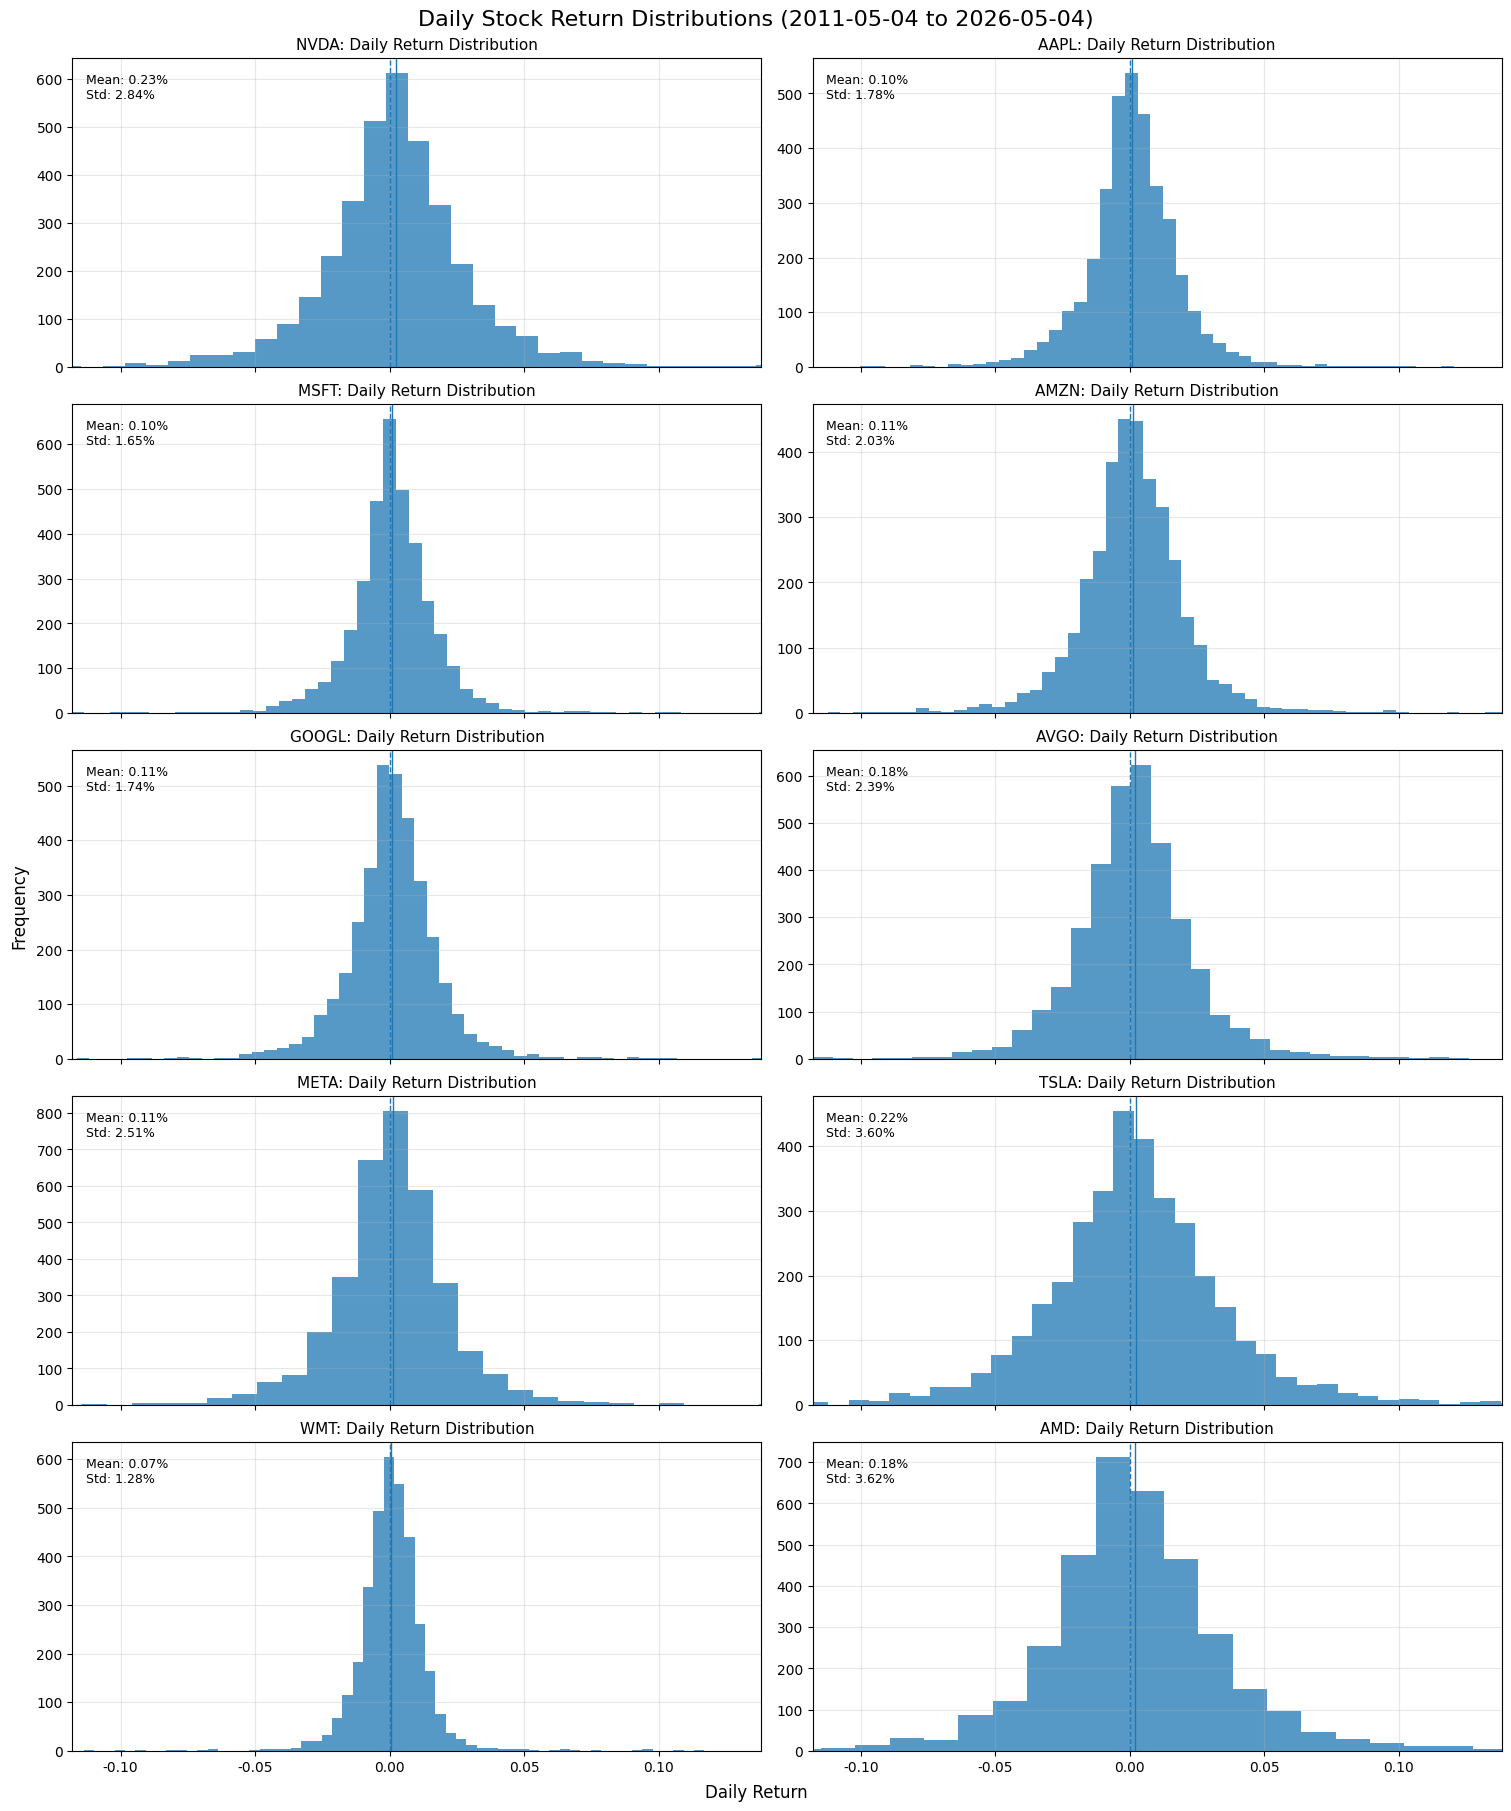

In [ ]:
from matplotlib.ticker import FormatStrFormatter, PercentFormatter

# Format dates for visualization title
start_str = start_date.strftime("%Y-%m-%d")
end_str = end_date.strftime("%Y-%m-%d")

# Better visualization for stock return distribution
fig, axes = plt.subplots(
    5, 2,
    figsize=(15, 18),
    sharex=True,
    constrained_layout=True
)

axes = axes.flatten()

# common x-range for comparison
x_min = returns[tickers].quantile(0.005).min()
x_max = returns[tickers].quantile(0.995).max()

for ax, ticker in zip(axes, tickers):
    data = returns[ticker].dropna()

    ax.hist(data, bins=60, alpha=0.75)
    ax.axvline(0, linestyle="--", linewidth=1)
    ax.axvline(data.mean(), linestyle="-", linewidth=1)

    ax.set_title(f"{ticker}: Daily Return Distribution", fontsize=11)
    ax.set_xlim(x_min, x_max)

    # show raw return values on x-axis
    ax.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))

    ax.grid(True, alpha=0.3)

    ax.text(
        0.02, 0.95,
        f"Mean: {data.mean():.2%}\nStd: {data.std():.2%}",
        transform=ax.transAxes,
        va="top",
        fontsize=9
    )

fig.suptitle(
    f"Daily Stock Return Distributions ({start_str} to {end_str})",
    fontsize=16
)

fig.supxlabel("Daily Return")
fig.supylabel("Frequency")

plt.show()

## Data Splitting

In [ ]:
# Split data for backtesting (e.g., 80% in-sample, 20% out-sample)
split_ratio = 0.8
split_index = int(len(returns) * split_ratio)

# First 80% for training, last 20% for testing
train_returns = returns.iloc[:split_index]
test_returns = returns.iloc[split_index:]

# Print the date ranges for train and test sets
print(f"Train period: {train_returns.index[0]} to {train_returns.index[-1]}")
print(f"Test period: {test_returns.index[0]} to {test_returns.index[-1]}")

Train period: 2012-05-21 00:00:00 to 2023-07-14 00:00:00
Test period: 2023-07-17 00:00:00 to 2026-05-01 00:00:00


## Risk Metrics Calculation

In [66]:
# VaR: percentile of returns at confidence level
def historical_var(returns, confidence=0.95):
    clean = returns.dropna()
    return -np.percentile(clean, 100 * (1 - confidence))

# CVaR: mean of returns up to VaR threshold
def historical_cvar(returns, confidence=0.95):
    clean = returns.dropna()
    # Compute the VaR threshold by sorting returns and select the value that is 5th percentile of loss distribution 
    var = historical_var(clean, confidence)
    # Select every returns that below the VaR threshold
    tail = clean[clean <= -var]
    return -tail.mean() if len(tail) > 0 else np.nan

# Annualize daily metrics (VaR/CVaR) using square root of time scaling
def annualize_metric(metric_daily, trading_days=252):
    # Annalized metrics - we have 252 trading days in a year 
    return metric_daily * np.sqrt(trading_days)

# Risk Metrics: Compute VaR and CVaR for each stock at specified confidence level, both daily and annualized
def compute_risk_metrics(returns_df, confidence=0.95, trading_days=252):
    results = []
    for ticker in returns_df.columns:
        var_d = historical_var(returns_df[ticker], confidence)
        cvar_d = historical_cvar(returns_df[ticker], confidence)
        var_a = annualize_metric(var_d, trading_days)
        cvar_a = annualize_metric(cvar_d, trading_days)
        results.append({
            'ticker': ticker,
            'confidence': confidence,
            'VaR_daily': var_d,
            'CVaR_daily': cvar_d,
            'VaR_annualized': var_a,
            'CVaR_annualized': cvar_a
        })
    return pd.DataFrame(results).set_index(['ticker', 'confidence'])

In [67]:
# Example: Compute risk metrics for the default confidence level (e.g. 95%)
confidence_level = 0.95
risk_metrics = compute_risk_metrics(returns, confidence=confidence_level)
print(f"Risk metrics at {int(confidence_level * 100)}% confidence")
print(risk_metrics)

Risk metrics at 95% confidence
                   VaR_daily  CVaR_daily  VaR_annualized  CVaR_annualized
ticker confidence                                                        
NVDA   0.95         0.040904    0.061212        0.649332         0.971713
AAPL   0.95         0.026664    0.040614        0.423272         0.644723
MSFT   0.95         0.025040    0.037343        0.397493         0.592795
AMZN   0.95         0.029879    0.045398        0.474320         0.720668
GOOGL  0.95         0.025182    0.038678        0.399746         0.614001
AVGO   0.95         0.033451    0.050262        0.531014         0.797886
META   0.95         0.035863    0.055117        0.569300         0.874960
TSLA   0.95         0.051226    0.077370        0.813182         1.228206
WMT    0.95         0.017462    0.028265        0.277207         0.448689
AMD    0.95         0.051928    0.077693        0.824324         1.233340


## CVaR Portfolio Optimization

### Optimization Problem Formulation

In [69]:
# CVaR portfolio optimization utilities
def portfolio_return(weights, returns_df):
    return returns_df.dot(weights)

# Calculate portfolio metrics (mean return, VaR, CVaR) for given weights and returns dataframe
def portfolio_metrics(weights, returns_df, confidence=0.95, trading_days=252):
    port_r = portfolio_return(weights, returns_df)
    mean_d = port_r.mean()
    var_d = historical_var(port_r, confidence)
    cvar_d = historical_cvar(port_r, confidence)
    var_a = annualize_metric(var_d, trading_days)
    cvar_a = annualize_metric(cvar_d, trading_days)
    return {
        'mean_daily': mean_d,
        'VaR_daily': var_d,
        'CVaR_daily': cvar_d,
        'VaR_annualized': var_a,
        'CVaR_annualized': cvar_a
    }

# Objective function for CVaR optimization (minimize portfolio CVaR)
def cvar_objective(weights, returns_df, confidence=0.95):
    return portfolio_metrics(weights, returns_df, confidence)['CVaR_daily']

In [ ]:
# Number of assets (e.g. 10)
n_assets = len(tickers)
# Initialize equal weighted
init_weights = np.repeat(1 / n_assets, n_assets)
# Constraints: weights sum to 1, and each weight between 0 and 1 (no short selling)
bounds = tuple((0, 1) for _ in range(n_assets))

constraints = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1},)

result_cvar = minimize(
    cvar_objective,
    init_weights,
    args=(train_returns, confidence_level),
    method='SLSQP',
    bounds=bounds,
    constraints=constraints,
    options={'ftol': 1e-9, 'disp': False}
)

optimal_weights = result_cvar.x
optimal_portfolio = portfolio_metrics(optimal_weights, train_returns, confidence_level)

# Equal-weighted benchmark
equal_weights = init_weights
benchmark_portfolio = portfolio_metrics(equal_weights, train_returns, confidence_level)

print('CVaR optimization success:', result_cvar.success)
print('Optimal weights:')
print(pd.Series(optimal_weights, index=tickers).round(4))
print('\nOptimal portfolio metrics:')
for name, value in optimal_portfolio.items():
    print(f'{name}: {value:.6f}')
print('\nEqual-weighted portfolio metrics:')
for name, value in benchmark_portfolio.items():
    print(f'{name}: {value:.6f}')

CVaR optimization success: True
Optimal weights:
NVDA     0.0000
AAPL     0.0011
MSFT     0.0880
AMZN     0.0401
GOOGL    0.1419
AVGO     0.0679
META     0.0000
TSLA     0.0000
WMT      0.6610
AMD      0.0000
dtype: float64

Optimal portfolio metrics:
mean_daily: 0.000699
VaR_daily: 0.016254
CVaR_daily: 0.025108
VaR_annualized: 0.258017
CVaR_annualized: 0.398577

Equal-weighted portfolio metrics:
mean_daily: 0.001363
VaR_daily: 0.025789
CVaR_daily: 0.037704
VaR_annualized: 0.409383
CVaR_annualized: 0.598532


### Out-of-sample Evaluation

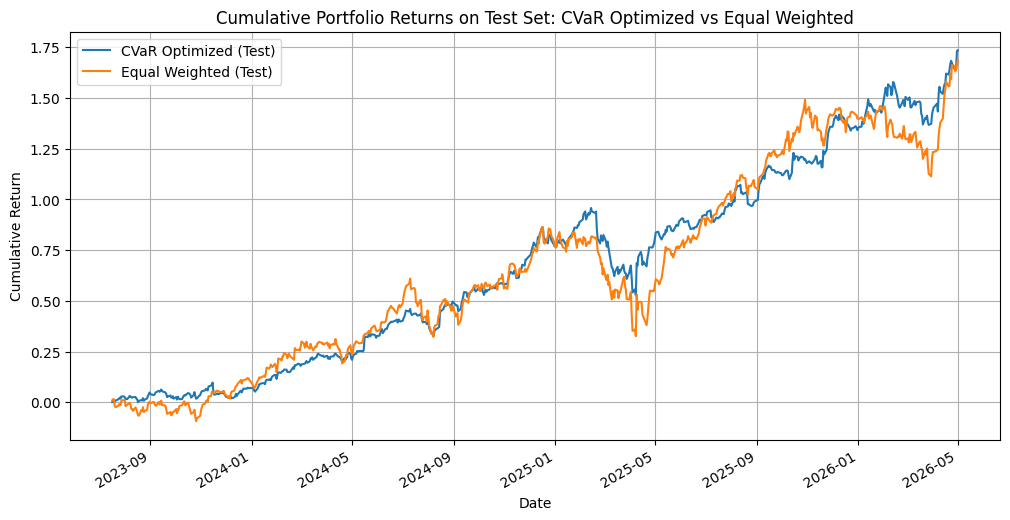

In [71]:
# Plot optimized portfolio vs equal-weighted benchmark on TEST data
portfolio_returns_opt_test = portfolio_return(optimal_weights, test_returns)
portfolio_returns_eq_test = portfolio_return(equal_weights, test_returns)

plt.figure(figsize=(12, 6))
((1 + portfolio_returns_opt_test).cumprod() - 1).plot(label='CVaR Optimized (Test)')
((1 + portfolio_returns_eq_test).cumprod() - 1).plot(label='Equal Weighted (Test)')
plt.title('Cumulative Portfolio Returns on Test Set: CVaR Optimized vs Equal Weighted')
plt.ylabel('Cumulative Return')
plt.xlabel('Date')
plt.legend()
plt.grid(True)
plt.show()

### (Optional) Mean-CVaR Optimization 

In [ ]:
# Code

## Backtesting & Benchmarking

### CVaR-Portfolio Returns 

In [74]:
# Compute test-set metrics for optimized portfolio
test_opt_portfolio = portfolio_metrics(optimal_weights, test_returns, confidence_level)
test_benchmark_portfolio = portfolio_metrics(equal_weights, test_returns, confidence_level)

print('Test-Set Metrics for CVaR Optimized Portfolio:')
for name, value in test_opt_portfolio.items():
    print(f'{name}: {value:.6f}')
print('\nTest-Set Metrics for Equal-Weighted Benchmark:')
for name, value in test_benchmark_portfolio.items():
    print(f'{name}: {value:.6f}')

Test-Set Metrics for CVaR Optimized Portfolio:
mean_daily: 0.001496
VaR_daily: 0.015129
CVaR_daily: 0.022943
VaR_annualized: 0.240165
CVaR_annualized: 0.364204

Test-Set Metrics for Equal-Weighted Benchmark:
mean_daily: 0.001540
VaR_daily: 0.025018
CVaR_daily: 0.035325
VaR_annualized: 0.397156
CVaR_annualized: 0.560763


### Portfolio Variants Comparison 

In [ ]:
# Objective: Equal-weighted, CVaR, Mean-CVaR,... on test set performance comparison
strategies = {
    'CVaR Optimized': test_opt_portfolio,
    'Equal Weighted': test_benchmark_portfolio,
    # Add more if available, e.g., 'Mean-CVaR': test_mean_cvar_portfolio
}
comparison_df = pd.DataFrame(strategies).T
print(comparison_df)

                mean_daily  VaR_daily  CVaR_daily  VaR_annualized  \
CVaR Optimized    0.001496   0.015129    0.022943        0.240165   
Equal Weighted    0.001540   0.025018    0.035325        0.397156   

                CVaR_annualized  
CVaR Optimized         0.364204  
Equal Weighted         0.560763  


In [ ]:
# Visualization: Bar chart for key metrics
metrics_to_plot = ['mean_daily', 'CVaR_daily', 'VaR_daily']
comparison_df[metrics_to_plot].plot(kind='bar', figsize=(10, 6))
plt.title('Portfolio Metrics Comparison on Test Set')
plt.ylabel('Value')
plt.xticks(rotation=45)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.show()

### Model Performance Metrics 

#### Sharpe Ratio

In [75]:
# Sharpe Ratio (annualized, assuming risk-free rate = 0 for simplicity)
def sharpe_ratio(portfolio_returns, trading_days=252):
    mean_ann = portfolio_returns.mean() * trading_days
    std_ann = portfolio_returns.std() * np.sqrt(trading_days)
    return mean_ann / std_ann if std_ann != 0 else np.nan

sharpe_opt = sharpe_ratio(portfolio_returns_opt_test)
sharpe_eq = sharpe_ratio(portfolio_returns_eq_test)
print(f'Sharpe Ratio (Test Set) - CVaR Optimized: {sharpe_opt:.4f}')
print(f'Sharpe Ratio (Test Set) - Equal Weighted: {sharpe_eq:.4f}')


Sharpe Ratio (Test Set) - CVaR Optimized: 2.1332
Sharpe Ratio (Test Set) - Equal Weighted: 1.5012


#### (Optional) Confidence Level Sensitivity 

In [ ]:
# Sensitivity analysis on test set
confidence_levels = [0.90, 0.95, 0.99]
sensitivity_results = {}
for conf in confidence_levels:
    metrics = portfolio_metrics(optimal_weights, test_returns, conf)
    sensitivity_results[conf] = metrics['CVaR_annualized']
print('CVaR Sensitivity to Confidence Level (Test Set):')
for conf, cvar in sensitivity_results.items():
    print(f'{int(conf*100)}%: {cvar:.6f}')

CVaR Sensitivity to Confidence Level (Test Set):
90%: 0.283826
95%: 0.364204
99%: 0.604667


In [ ]:
# Visualization: Line plot for sensitivity
plt.figure(figsize=(8, 5))
plt.plot([int(c*100) for c in sensitivity_results.keys()], list(sensitivity_results.values()), marker='o')
plt.title('CVaR Sensitivity to Confidence Level (Test Set)')
plt.xlabel('Confidence Level (%)')
plt.ylabel('Annualized CVaR')
plt.grid(True, alpha=0.3)
plt.show()

#### (Optional) Monte-Carlo Simulation 

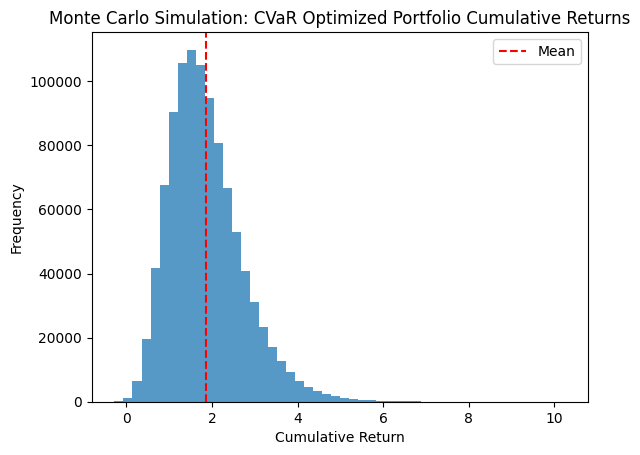

In [79]:
# Monte Carlo simulation (e.g., 10000000 simulations of test-period returns)
n_simulations = 1000000
simulated_cum_returns = []
for _ in range(n_simulations):
    sim_returns = np.random.choice(portfolio_returns_opt_test, size=len(portfolio_returns_opt_test), replace=True)
    cum_return = (1 + sim_returns).prod() - 1
    simulated_cum_returns.append(cum_return)

plt.hist(simulated_cum_returns, bins=50, alpha=0.75)
plt.axvline(np.mean(simulated_cum_returns), color='red', linestyle='--', label='Mean')
plt.title('Monte Carlo Simulation: CVaR Optimized Portfolio Cumulative Returns')
plt.xlabel('Cumulative Return')
plt.ylabel('Frequency')
plt.legend()
plt.show()

#### Efficient Frontier (CVaR-based)

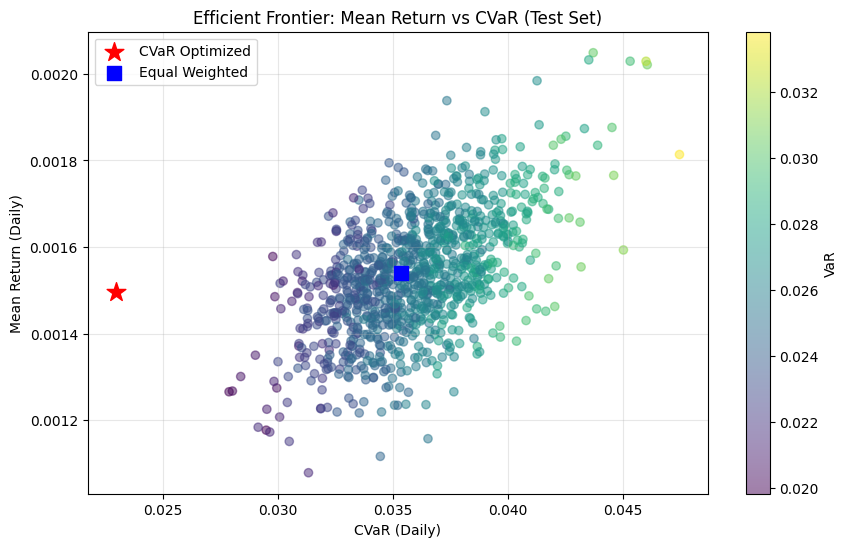

In [80]:
# Generate random portfolios for efficient frontier
n_portfolios = 1000
results = np.zeros((3, n_portfolios))
weights_record = []

for i in range(n_portfolios):
    weights = np.random.random(n_assets)
    weights /= np.sum(weights)
    weights_record.append(weights)
    
    port_metrics = portfolio_metrics(weights, test_returns, confidence_level)
    results[0,i] = port_metrics['mean_daily']  # Mean return
    results[1,i] = port_metrics['CVaR_daily']  # CVaR
    results[2,i] = port_metrics['VaR_daily']   # VaR (optional)

# Plot efficient frontier: Mean return vs CVaR
plt.figure(figsize=(10, 6))
plt.scatter(results[1,:], results[0,:], c=results[2,:], cmap='viridis', alpha=0.5)
plt.colorbar(label='VaR')
plt.scatter(test_opt_portfolio['CVaR_daily'], test_opt_portfolio['mean_daily'], 
            color='red', marker='*', s=200, label='CVaR Optimized')
plt.scatter(test_benchmark_portfolio['CVaR_daily'], test_benchmark_portfolio['mean_daily'], 
            color='blue', marker='s', s=100, label='Equal Weighted')
plt.title('Efficient Frontier: Mean Return vs CVaR (Test Set)')
plt.xlabel('CVaR (Daily)')
plt.ylabel('Mean Return (Daily)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()